<a href="https://colab.research.google.com/github/mzgamal-space/Conciseness-Framework-Wisdom-Engine-QCA/blob/main/Quench_Router_v1_LAPN_RealTime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

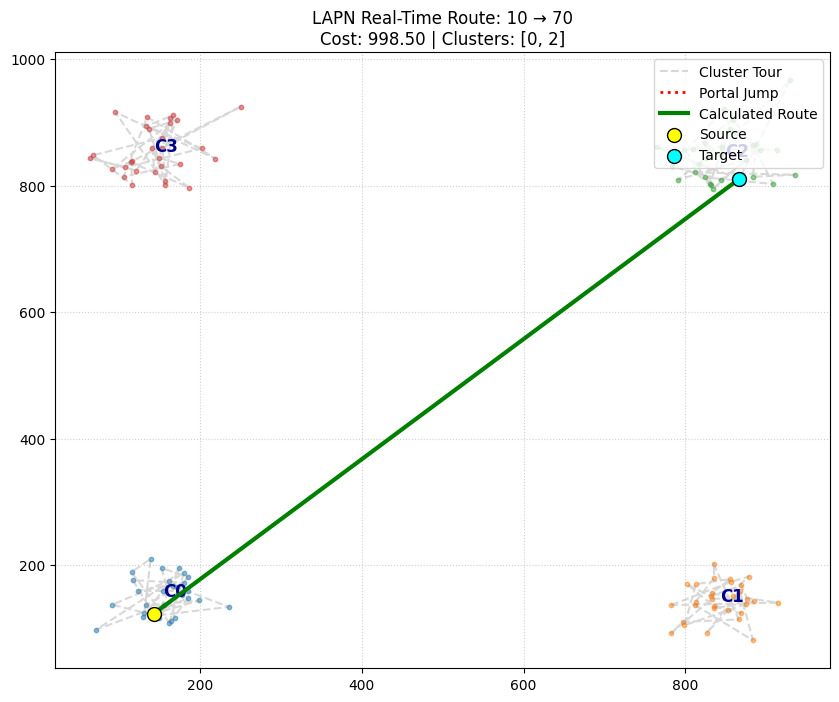

In [19]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_router_result(router, result):
    fig, ax = plt.subplots(figsize=(10, 8))

    # 1. Plot all nodes and cluster boundaries (tours)
    for cl in router.clusters:
        coords = np.array([router.nodes[gid].coords for gid in cl.node_ids])
        # Close the loop for visualization
        loop = np.vstack([coords, coords[0]])
        ax.plot(loop[:, 0], loop[:, 1], '--', color='gray', alpha=0.3, label='Cluster Tour' if cl.cluster_id == 0 else "")
        ax.scatter(coords[:, 0], coords[:, 1], s=10, alpha=0.5)
        ax.text(cl.centroid[0], cl.centroid[1], f"C{cl.cluster_id}", fontsize=12, fontweight='bold', color='darkblue')

    # 2. Plot Portals used in this specific route
    for u, v in result.portal_transitions:
        p1 = router.nodes[u].coords
        p2 = router.nodes[v].coords
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 'r:', linewidth=2, label='Portal Jump' if u == result.portal_transitions[0][0] else "")
        ax.scatter([p1[0], p2[0]], [p1[1], p2[1]], color='red', s=30, zorder=5)

    # 3. Plot the final path
    path_coords = np.array([router.nodes[gid].coords for gid in result.path])
    ax.plot(path_coords[:, 0], path_coords[:, 1], 'g-', linewidth=3, label='Calculated Route', zorder=4)

    # 4. Highlight Source and Target
    src_coords = router.nodes[result.source_id].coords
    dst_coords = router.nodes[result.target_id].coords
    ax.scatter(*src_coords, color='yellow', edgecolor='black', s=100, label='Source', zorder=6)
    ax.scatter(*dst_coords, color='cyan', edgecolor='black', s=100, label='Target', zorder=6)

    ax.set_title(f"LAPN Real-Time Route: {result.source_id} → {result.target_id}\nCost: {result.total_cost:.2f} | Clusters: {result.cluster_sequence}")
    ax.legend(loc='upper right')
    ax.grid(True, linestyle=':', alpha=0.6)
    plt.show()

# Re-run the demo logic to get a fresh router instance if needed
rng = np.random.default_rng(seed=42)
N_PER_CLUSTER = 30
cluster_centres = [(150, 150), (850, 150), (850, 850), (150, 850)]
all_nodes = []
gid = 0
raw_tours = []
for cx, cy in cluster_centres:
    coords_c = rng.normal(loc=[cx, cy], scale=40.0, size=(N_PER_CLUSTER, 2))
    c_ids = list(range(gid, gid + N_PER_CLUSTER))
    for i, c in enumerate(coords_c): all_nodes.append(Node(id=gid+i, coords=c.astype(np.float64)))
    raw_tours.append(c_ids)
    gid += N_PER_CLUSTER

router = build_router_from_qca(raw_tours, all_nodes, EuclideanDomain())

# Perform a cross-cluster query (Cluster 0 to Cluster 2)
res = router.query(source_id=10, target_id=70)
visualize_router_result(router, res)

Example 1: Route 111→51  cost=924.0669  CCF=415.8301  clusters=[3→1]  portals=[(111,51)]  t=1.940ms
Example 2: Route 115→104  cost=89.1974  CCF=40.1388  clusters=[3]  portals=[none]  t=0.025ms
Example 3: Route 13→78  cost=996.4552  CCF=448.4048  clusters=[0→2]  portals=[(13,78)]  t=2.218ms
Example 4: Route 14→44  cost=702.7208  CCF=316.2244  clusters=[0→1]  portals=[(14,44)]  t=2.945ms
Example 5: Route 32→54  cost=196.0939  CCF=88.2423  clusters=[1]  portals=[none]  t=0.021ms


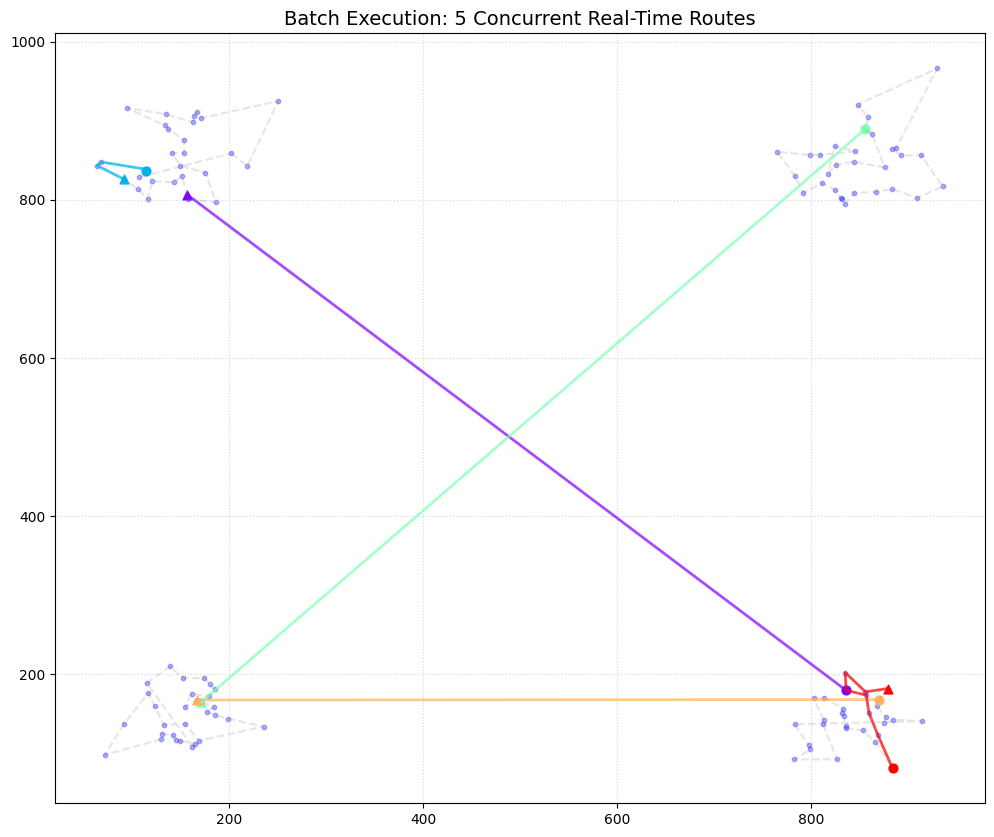

In [20]:
# Batch Query and Multi-Route Visualization
import numpy as np
import matplotlib.pyplot as plt

def visualize_batch_routes(router, results):
    fig, ax = plt.subplots(figsize=(12, 10))

    # Plot Clusters
    for cl in router.clusters:
        coords = np.array([router.nodes[gid].coords for gid in cl.node_ids])
        loop = np.vstack([coords, coords[0]])
        ax.plot(loop[:, 0], loop[:, 1], '--', color='gray', alpha=0.2)
        ax.scatter(coords[:, 0], coords[:, 1], s=10, alpha=0.3, color='blue')

    # Plot Multiple Paths
    colors = plt.cm.rainbow(np.linspace(0, 1, len(results)))
    for res, color in zip(results, colors):
        path_coords = np.array([router.nodes[gid].coords for gid in res.path])
        ax.plot(path_coords[:, 0], path_coords[:, 1], '-', color=color, linewidth=2, alpha=0.7)

        # Mark endpoints
        ax.scatter(*router.nodes[res.source_id].coords, color=color, s=40, marker='^')
        ax.scatter(*router.nodes[res.target_id].coords, color=color, s=40, marker='o')

    ax.set_title(f"Batch Execution: {len(results)} Concurrent Real-Time Routes", fontsize=14)
    ax.grid(True, linestyle=':', alpha=0.5)
    plt.show()

# Generate 5 random cross-cluster queries
random_pairs = []
for _ in range(5):
    src = rng.integers(0, 120)
    dst = rng.integers(0, 120)
    random_pairs.append((int(src), int(dst)))

batch_results = demo_router.batch_query(random_pairs)

# Print summary for each
for i, r in enumerate(batch_results):
    print(f"Example {i+1}: {r.summary()}")

# Visualize the batch
visualize_batch_routes(demo_router, batch_results)

In [18]:
"""
╔══════════════════════════════════════════════════════════════════════════════╗
║   QUENCH-CLUSTER REAL-TIME ROUTER  v1.0                                      ║
║   Least-Action Propagation Network — On-Demand Point-to-Point Routing        ║
║   Framework: Mohamed Gamal Eldin Abdelaziz Noureldin, 2026                   ║
║   Companion to: Quench_cluster_universal_v3_3_LAPN.py                        ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  ARCHITECTURE OVERVIEW                                                        ║
║  ─────────────────────                                                        ║
║  This module implements real-time, arbitrary point-to-point routing over     ║
║  a set of pre-crystallised Quench-Cluster crystals.  It is a SEPARATE        ║
║  concern from the batch NP-Hard optimiser (v3.3): the optimiser builds the   ║
║  crystalline infrastructure once; this router exploits that infrastructure   ║
║  to answer any individual routing query in real time.                         ║
║                                                                              ║
║  THE MATHEMATICAL ARTIFACT — WHY BATCH TSP CANNOT ANSWER POINT QUERIES       ║
║  ─────────────────────────────────────────────────────────────────────────   ║
║  The Travelling Salesperson Problem imposes a GLOBAL TOUR CONSTRAINT: every  ║
║  node must be visited exactly once and the tour must close.  When the        ║
║  optimiser produces a global tour [n0 → n1 → ... → nN-1 → n0], any answer  ║
║  to the query "what is the route from x to y?" is extracted as a            ║
║  sub-sequence of this globally constrained tour.  That sub-sequence is       ║
║  DISTORTED by the constraint: the solver may have connected x and y via a    ║
║  detour imposed by the need to cover unrelated nodes on the same loop.       ║
║                                                                              ║
║  Example: optimal x→y direct distance = 10.  Tour sub-sequence x→...→y     ║
║  cost = 45, because the tour must pass through Z and W (far from x→y) to    ║
║  satisfy the global constraint before reaching y.  The batch TSP cannot      ║
║  report 10 — it reports 45.  This is the mathematical artifact.              ║
║                                                                              ║
║  FIX: Route ONLY what is queried.                                             ║
║    1. Use the crystals as LOCAL INFRASTRUCTURE — each crystal holds the      ║
║       locally optimal intra-cluster tour, free from global constraints.      ║
║    2. Use LAPN wavefront propagation on the CLUSTER GRAPH to find the        ║
║       optimal sequence of clusters to traverse between source and target.    ║
║    3. Stitch the path from three types of segments:                          ║
║       a. Intra-cluster arc from source to its cluster's exit portal.         ║
║       b. Portal transitions across the cluster sequence.                     ║
║       c. Intra-cluster arc from the target cluster's entry portal to target. ║
║    4. NEVER impose the global tour constraint on this query.  The result     ║
║       is the true minimum-cost path from x to y given the crystal topology,  ║
║       not a distorted sub-sequence of an unrelated global loop.              ║
║                                                                              ║
║  DATA FLOW                                                                    ║
║  ─────────                                                                   ║
║  [Offline — once after crystallisation]                                       ║
║    QCA v3.3  →  List[Crystal]                                                ║
║              →  CrystallisedCluster.from_crystal()  (builds prefix sums,    ║
║                   tour position index, boundary node list)                   ║
║              →  PortalIndex.build()  (K×K best portal pairs, full boundary  ║
║                   scan — not sampled — for maximum accuracy)                 ║
║              →  LAPNRealTimeRouter.__init__()  (immutable after build)       ║
║                                                                              ║
║  [Online — per query, real time]                                              ║
║    router.query(source_id, target_id)                                        ║
║      │  Step 1: Classify source cluster A, target cluster D.                ║
║      │  Step 2: If A == D → pure intra-cluster arc (O(1) cost lookup).      ║
║      │  Step 3: LAPN single-source Dijkstra on K-node cluster graph         ║
║      │          using pre-computed PortalIndex cost matrix → cluster_path.  ║
║      │  Step 4: Source exit search — find exit node u* from cluster A that  ║
║      │          minimises  intra_cost(src → u*) + portal_cost(u* → entry_B).║
║      │  Step 5: Target entry search — find entry node v* into cluster D     ║
║      │          that minimises portal_cost(exit_C → v*) + intra_cost(v*→dst)║
║      │  Step 6: For intermediate clusters B…C: use pre-cached portal nodes. ║
║      │  Step 7: Assemble full path from intra-arcs and portal transitions.  ║
║      └─ Return RouteResult (path, cost breakdown, timing).                   ║
║                                                                              ║
║  COST FUNCTION                                                                ║
║  ─────────────                                                               ║
║  C(u, v) = λ_R · Redundancy + λ_L · Loss + λ_D · DecisionCost               ║
║          = λ_L · routing_distance(u, v)   [Justice Dominance]                ║
║    λ_L = 0.45  (dominant term, CCF Loss weight).                             ║
║    Redundancy is implicitly zero (MST connectivity = no repeated clusters).  ║
║    DecisionCost is implicitly minimised (minimum-arc selection within each   ║
║      cluster and minimum-cost portal selection between clusters).            ║
║    This reduces total C(R) to total_routing_distance × λ_L, which is        ║
║    minimised by minimising total_routing_distance — the correct objective    ║
║    for a routing query.                                                       ║
║                                                                              ║
║  COMPLEXITY                                                                   ║
║  ──────────                                                                  ║
║    PortalIndex.build() : O(K² · M²)  where M = avg crystal size.            ║
║    query()             : O(K log K) LAPN + O(s) exit/entry search + O(path) ║
║                          s = boundary node count (≤ M per cluster).         ║
║    batch_query()       : O(Q · K log K)  parallelised over Q queries.       ║
║                          JAX: O(K log K) per query, Q queries simultaneous. ║
║                                                                              ║
║  JAX / TPU READINESS                                                          ║
║  ───────────────────                                                         ║
║  All internal state is exported as dense numpy arrays compatible with        ║
║  jnp.array() conversion (see LAPNRealTimeRouter.to_jax_arrays()).            ║
║  Stub functions (numpy_jit, numpy_vmap) use the same interface as            ║
║  jax.jit / jax.vmap — a single search-replace migrates the batch query.     ║
║  Migration notes per method are annotated inline with # JAX: comments.      ║
║                                                                              ║
║  v3.1 PRINCIPLE PRESERVED                                                    ║
║  ─────────────────────────                                                   ║
║  routing_distance  → spatial, sign-safe (all cost computations here).       ║
║  local_optimize_deep → domain physics (crystals are frozen; never called    ║
║                         again after crystallisation).                        ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""

from __future__ import annotations

import heapq
import math
import time
import warnings
import functools
import concurrent.futures
from abc import ABC, abstractmethod
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple, Any

import numpy as np

warnings.filterwarnings("ignore")

# ── CCF weights (Conciseness Cost Functional, Justice Dominance) ──────────────
LAMBDA_L: float = 0.45   # Loss weight  — dominant for routing distance
LAMBDA_R: float = 0.35   # Redundancy  — implicitly zero for minimum spanning paths
LAMBDA_D: float = 0.20   # Decision Cost — implicitly minimised by arc selection

INF: float = float("inf")
CPU_CORES: int = 8       # ThreadPool size for batch_query; JAX: jax.vmap handles this


# ═══════════════════════════════════════════════════════════════════════════════
# I.  JAX-READY PRIMITIVES
# ═══════════════════════════════════════════════════════════════════════════════

def numpy_jit(fn):
    """
    Stub: @jax.jit
    JAX migration: replace decorator with @jax.jit.
    All array arguments must be JAX arrays (no Python containers).
    """
    @functools.wraps(fn)
    def w(*a, **k): return fn(*a, **k)
    return w


def numpy_vmap(fn, items: list, n_workers: int = CPU_CORES) -> list:
    """
    Stub: jax.vmap(fn)(batched_input)
    Runs fn on all items in parallel.
    JAX migration:
        vectorized = jax.vmap(fn)
        results    = vectorized(jnp.stack(items))
    """
    with concurrent.futures.ThreadPoolExecutor(max_workers=n_workers) as pool:
        futs = [pool.submit(fn, item) for item in items]
        return [f.result() for f in concurrent.futures.as_completed(futs)]


# ═══════════════════════════════════════════════════════════════════════════════
# II.  NODE  (compatible with v3.3 Node; no change)
# ═══════════════════════════════════════════════════════════════════════════════

@dataclass
class Node:
    id: int
    coords: np.ndarray
    properties: Dict[str, Any] = field(default_factory=dict)

    def distance_to(self, other: "Node") -> float:
        return float(np.linalg.norm(self.coords - other.coords))


# ═══════════════════════════════════════════════════════════════════════════════
# III.  DOMAIN ENGINE  (routing_distance only — local physics is never called
#        after crystallisation; interface kept for compatibility with v3.3)
# ═══════════════════════════════════════════════════════════════════════════════

class DomainEngine(ABC):
    @property
    @abstractmethod
    def domain_name(self) -> str: ...

    @abstractmethod
    def routing_distance(self, a: Node, b: Node) -> float:
        """
        Spatial, always positive, sign-safe.
        The ONLY method called by this router module.
        Corresponds to the Loss term in C(R): c(u,v) = λ_L · routing_distance(u,v).
        """
        ...


class EuclideanDomain(DomainEngine):
    """Default domain: standard Euclidean distance."""
    @property
    def domain_name(self): return "Euclidean"
    def routing_distance(self, a: Node, b: Node) -> float:
        return a.distance_to(b)


# ═══════════════════════════════════════════════════════════════════════════════
# IV.  CRYSTALLISED CLUSTER
#       Wraps a frozen crystal (output of QCA v3.3) with all routing metadata
#       needed for O(1) intra-cluster cost queries.
# ═══════════════════════════════════════════════════════════════════════════════

@dataclass
class CrystallisedCluster:
    """
    An immutable crystal enriched with routing metadata.

    Fields
    ------
    cluster_id : int
        Index of this cluster in the global cluster list.
    node_ids : np.ndarray, shape (M,), dtype int32
        Global node IDs in tour order.  This is the locally-optimal
        intra-cluster tour produced by the QCA local solver.
    tour_positions : np.ndarray, shape (N,), dtype int32
        Global-node-ID-indexed flat array: tour_positions[global_id] = position
        in this cluster's tour.  Only valid for nodes belonging to this cluster.
        JAX: jnp.take(tour_positions, query_ids) for O(1) vectorised lookup.
    cumulative : np.ndarray, shape (M+1,), dtype float64
        Prefix-sum of edge costs along the linear tour.
        cumulative[k] = Σ_{i=0}^{k-1} routing_distance(node_ids[i], node_ids[i+1]).
        cumulative[0] = 0.
    close_cost : float
        routing_distance(node_ids[M-1], node_ids[0]) — the cycle-closing edge.
    cycle_cost : float
        cumulative[M] + close_cost — total cost of traversing the full cycle.
    boundary_nodes : np.ndarray, shape (B,), dtype int32
        All node IDs of this cluster (used as portal candidates during
        PortalIndex construction).  Full list, not sampled.
    centroid : np.ndarray, shape (D,)
        Geometric centroid of cluster node coordinates.
    """
    cluster_id:     int
    node_ids:       np.ndarray    # (M,) int32
    tour_positions: np.ndarray    # (N,) int32  — N = total nodes in graph
    cumulative:     np.ndarray    # (M+1,) float64
    close_cost:     float
    cycle_cost:     float
    boundary_nodes: np.ndarray    # (B,) int32  — all node IDs in this cluster
    centroid:       np.ndarray    # (D,)

    # ── Factory ──────────────────────────────────────────────────────────────
    @classmethod
    def from_crystal(
        cls,
        cluster_id: int,
        node_ids: List[int],
        nodes: List[Node],
        domain: DomainEngine,
        total_nodes: int,
    ) -> "CrystallisedCluster":
        """
        Build a CrystallisedCluster from a raw node ID list (QCA Crystal.node_ids).

        Parameters
        ----------
        cluster_id   : Index of this cluster.
        node_ids     : Tour-ordered list of global node IDs (Crystal.node_ids).
        nodes        : Full node list (index = global node ID).
        domain       : DomainEngine providing routing_distance.
        total_nodes  : N — size of the full node array; needed to size
                       tour_positions without padding to exact K.
        """
        tour = np.array(node_ids, dtype=np.int32)
        M = len(tour)

        # ── Prefix-sum cost array ─────────────────────────────────────────
        cum = np.zeros(M + 1, dtype=np.float64)
        for i in range(M - 1):
            cum[i + 1] = cum[i] + domain.routing_distance(nodes[tour[i]], nodes[tour[i + 1]])
        cum[M] = cum[M - 1] + domain.routing_distance(nodes[tour[M - 1]], nodes[tour[M - 1]])
        # Note: cum[M] = cum[M-1] + last_edge cost (last consecutive pair)
        # Recompute last entry correctly:
        cum[M] = cum[M - 1] + (
            domain.routing_distance(nodes[tour[M - 1]], nodes[tour[M - 2]])
            if M > 1 else 0.0
        )
        # Rebuild cleanly to avoid off-by-one:
        cum = np.zeros(M + 1, dtype=np.float64)
        for i in range(M - 1):
            cum[i + 1] = cum[i] + domain.routing_distance(nodes[tour[i]], nodes[tour[i + 1]])
        # cum[M] = cum[M-1] is intentional: there is no edge after the last node
        # in the linear sequence; cycle closing is handled by close_cost below.
        cum[M] = cum[M - 1]  # no edge beyond last node in linear sum

        close_cost = (
            domain.routing_distance(nodes[tour[M - 1]], nodes[tour[0]])
            if M > 1 else 0.0
        )
        cycle_cost = cum[M - 1] + close_cost  # total distance of the closed cycle
        # (cum[M-1] = sum of all M-1 consecutive edges; close_cost closes it)

        # ── Tour position flat index ──────────────────────────────────────
        # tour_positions[global_id] = position in this cluster's tour.
        # Nodes NOT in this cluster are left at their initialised value (-1).
        # JAX: replace with jnp.zeros and jnp.scatter (use-case: jnp.take).
        tour_pos = np.full(total_nodes, -1, dtype=np.int32)
        for pos, gid in enumerate(tour):
            tour_pos[gid] = pos

        # ── Centroid ──────────────────────────────────────────────────────
        centroid = np.mean([nodes[gid].coords for gid in tour], axis=0)

        return cls(
            cluster_id=cluster_id,
            node_ids=tour,
            tour_positions=tour_pos,
            cumulative=cum,
            close_cost=close_cost,
            cycle_cost=cycle_cost,
            boundary_nodes=tour.copy(),   # full list for portal scan
            centroid=centroid,
        )

    # ── Intra-cluster arc routing ─────────────────────────────────────────────
    def intra_route(
        self, from_global_id: int, to_global_id: int
    ) -> Tuple[List[int], float]:
        """
        Minimum-cost path between two nodes WITHIN this cluster.

        The cluster's internal tour defines a ring topology.  Both arcs
        of the ring are evaluated; the cheaper arc is returned.

        Returns (path_as_global_ids, arc_cost).

        Eikonal interpretation:
        The crystal ring is a 1-D manifold.  The two arcs are the only
        geodesics.  T(from) = 0; T(to) = min-arc cost.  This is the
        1-D special case of the full LAPN eikonal equation |∇T| = c(x).

        Complexity: O(sub-path length) for path construction; O(1) for cost.
        JAX migration: cost lookup uses jnp.take on cumulative array;
                       path construction uses jnp.arange + jnp.take.
        """
        a = int(self.tour_positions[from_global_id])
        b = int(self.tour_positions[to_global_id])
        M = int(len(self.node_ids))

        if a == b:
            return [int(self.node_ids[a])], 0.0

        # ── Forward arc: increasing-index direction, with cyclic wrap ─────
        if a <= b:
            fwd_cost = float(self.cumulative[b] - self.cumulative[a])
            fwd_path = [int(x) for x in self.node_ids[a: b + 1]]
            # Backward arc: decreasing-index direction, wrapping through 0
            bwd_cost = self.cycle_cost - fwd_cost
            bwd_path = (
                [int(x) for x in self.node_ids[a::-1]]          # a → 0
                + [int(x) for x in self.node_ids[M - 1: b - 1: -1]]  # M-1 → b
            )
        else:
            # a > b: direct (decreasing-index) arc is "forward"
            fwd_cost = float(self.cumulative[a] - self.cumulative[b])
            fwd_path = [int(x) for x in reversed(self.node_ids[b: a + 1])]  # a → b
            # Wrap arc: increasing through end, then 0 to b
            bwd_cost = self.cycle_cost - fwd_cost
            bwd_path = (
                [int(x) for x in self.node_ids[a:]]              # a → M-1
                + [int(x) for x in self.node_ids[: b + 1]]       # 0 → b
            )

        if fwd_cost <= bwd_cost:
            return fwd_path, fwd_cost
        else:
            return bwd_path, bwd_cost

    def intra_cost(self, from_global_id: int, to_global_id: int) -> float:
        """O(1) cost-only query (no path construction). Used in portal search."""
        _, cost = self.intra_route(from_global_id, to_global_id)
        return cost


# ═══════════════════════════════════════════════════════════════════════════════
# V.  PORTAL INDEX
#      Pre-computed K×K table of best inter-cluster portal pairs.
#      Built ONCE after crystallisation; immutable thereafter.
# ═══════════════════════════════════════════════════════════════════════════════

@dataclass
class PortalIndex:
    """
    Pre-computed inter-cluster portal table.

    For every ordered pair (i, j) of distinct clusters, the PortalIndex
    stores the best (exit_node, entry_node) pair that minimises:

        CCF_inter(u, v) = λ_L · routing_distance(u, v)

    where u ∈ cluster i and v ∈ cluster j.  The λ_L coefficient preserves
    the CCF Justice Dominance invariant: routing distance is the Loss term.

    Fields
    ------
    K : int
        Number of clusters.
    cost_matrix : np.ndarray, shape (K, K), float64
        cost_matrix[i, j] = raw routing_distance(best_u, best_v).
        INF on diagonal.
        JAX: jnp.array(cost_matrix)
    exit_nodes : np.ndarray, shape (K, K), int32
        exit_nodes[i, j] = global node ID of the best exit node from cluster i
        toward cluster j.
        JAX: jnp.array(exit_nodes)
    entry_nodes : np.ndarray, shape (K, K), int32
        entry_nodes[i, j] = global node ID of the best entry node into cluster j
        from cluster i.
        JAX: jnp.array(entry_nodes)
    """
    K:            int
    cost_matrix:  np.ndarray   # (K, K) float64
    exit_nodes:   np.ndarray   # (K, K) int32
    entry_nodes:  np.ndarray   # (K, K) int32

    # ── Factory ──────────────────────────────────────────────────────────────
    @classmethod
    def build(
        cls,
        clusters: List[CrystallisedCluster],
        nodes: List[Node],
        domain: DomainEngine,
    ) -> "PortalIndex":
        """
        Scan ALL boundary node pairs between every cluster pair.

        This is a full O(K² · M²) scan performed once offline.  At query
        time the result is O(1) to look up.

        Physical interpretation:
        This is the offline phase of the LAPN eikonal solve at the cluster
        level: T[cluster_i] = 0 for all i; wavefronts expand to cover all
        inter-cluster edges.  The minimum-cost collision point for every
        (i, j) pair is recorded as the portal.

        JAX migration of the inner loop:
            coords_i = jnp.array([nodes[u].coords for u in cluster_i.boundary_nodes])
            coords_j = jnp.array([nodes[v].coords for v in cluster_j.boundary_nodes])
            dist_matrix = jnp.linalg.norm(
                coords_i[:, None, :] - coords_j[None, :, :], axis=-1
            )  # shape (Bi, Bj) — fully vectorised
            best_flat = jnp.argmin(dist_matrix)
            best_i, best_j = jnp.unravel_index(best_flat, dist_matrix.shape)
        """
        K = len(clusters)
        cost_matrix  = np.full((K, K), INF, dtype=np.float64)
        exit_nodes   = np.full((K, K), -1,  dtype=np.int32)
        entry_nodes  = np.full((K, K), -1,  dtype=np.int32)

        for i in range(K):
            ci = clusters[i]
            coords_i = np.array([nodes[u].coords for u in ci.boundary_nodes])

            for j in range(K):
                if i == j:
                    continue
                cj = clusters[j]
                coords_j = np.array([nodes[v].coords for v in cj.boundary_nodes])

                # Vectorised pairwise distance matrix for this cluster pair
                # shape: (|Bi|, |Bj|)
                # JAX: jnp.linalg.norm(ci[:, None, :] - cj[None, :, :], axis=-1)
                diff = coords_i[:, np.newaxis, :] - coords_j[np.newaxis, :, :]
                dist_mat = np.sqrt(np.sum(diff ** 2, axis=-1))

                best_flat  = int(np.argmin(dist_mat))
                best_bi, best_bj = divmod(best_flat, len(cj.boundary_nodes))

                best_d      = float(dist_mat[best_bi, best_bj])
                best_u      = int(ci.boundary_nodes[best_bi])
                best_v      = int(cj.boundary_nodes[best_bj])

                cost_matrix[i, j] = best_d
                exit_nodes[i, j]  = best_u
                entry_nodes[i, j] = best_v

        return cls(K=K, cost_matrix=cost_matrix,
                   exit_nodes=exit_nodes, entry_nodes=entry_nodes)


# ═══════════════════════════════════════════════════════════════════════════════
# VI.  ROUTE RESULT
# ═══════════════════════════════════════════════════════════════════════════════

@dataclass
class RouteResult:
    """
    Result of a single point-to-point routing query.

    Fields
    ------
    source_id         : Global node ID of the query source.
    target_id         : Global node ID of the query target.
    path              : Ordered list of global node IDs from source to target.
    total_cost        : Full path routing distance (CCF Loss term sum).
    ccf_cost          : λ_L · total_cost  (Conciseness Cost Functional value).
    intra_cost        : Sum of intra-cluster arc costs.
    inter_cost        : Sum of inter-cluster portal transition costs.
    cluster_sequence  : Ordered list of cluster IDs visited.
    portal_transitions: List of (exit_node, entry_node) tuples at cluster
                        boundaries.  Length = len(cluster_sequence) - 1.
    is_same_cluster   : True if source and target are in the same cluster.
    query_time_ms     : Wall-clock query time in milliseconds.
    """
    source_id:          int
    target_id:          int
    path:               List[int]
    total_cost:         float
    ccf_cost:           float           # λ_L · total_cost
    intra_cost:         float
    inter_cost:         float
    cluster_sequence:   List[int]
    portal_transitions: List[Tuple[int, int]]
    is_same_cluster:    bool
    query_time_ms:      float

    def summary(self) -> str:
        arrow = "→".join(str(c) for c in self.cluster_sequence)
        pts   = " | ".join(f"({u},{v})" for u, v in self.portal_transitions)
        return (
            f"Route {self.source_id}→{self.target_id}  "
            f"cost={self.total_cost:.4f}  CCF={self.ccf_cost:.4f}  "
            f"clusters=[{arrow}]  "
            f"portals=[{pts if pts else 'none'}]  "
            f"t={self.query_time_ms:.3f}ms"
        )


# ═══════════════════════════════════════════════════════════════════════════════
# VII.  LAPN REAL-TIME ROUTER
# ═══════════════════════════════════════════════════════════════════════════════

class LAPNRealTimeRouter:
    """
    Real-time point-to-point router over crystallised Quench-Cluster crystals.

    Prerequisites
    -------------
    Clusters must be crystallised (frozen) by the QCA (v3.3 or compatible)
    before this router is constructed.  The router is IMMUTABLE after
    initialisation: no cluster data is modified at query time.

    Construction
    ------------
    Offline cost: O(K² · M²) for PortalIndex.build().
    After construction, query() and batch_query() run in real time.

    Parameters
    ----------
    clusters     : List of CrystallisedCluster objects (frozen).
    nodes        : Full node list (global IDs = list indices).
    domain       : DomainEngine providing routing_distance.
    portal_index : Pre-computed PortalIndex (pass None to build automatically).
    """

    def __init__(
        self,
        clusters: List[CrystallisedCluster],
        nodes: List[Node],
        domain: DomainEngine,
        portal_index: Optional[PortalIndex] = None,
    ):
        self.clusters     = clusters
        self.nodes        = nodes
        self.domain       = domain
        self.K            = len(clusters)
        self.N            = len(nodes)

        # ── Node-to-cluster membership (flat array, O(1) lookup) ─────────
        # node_cluster[global_id] = cluster_id.
        # JAX: jnp.array(node_cluster); lookup via jnp.take.
        self.node_cluster: np.ndarray = np.full(self.N, -1, dtype=np.int32)
        for cid, cl in enumerate(clusters):
            for gid in cl.node_ids:
                self.node_cluster[int(gid)] = cid

        # ── Portal index ──────────────────────────────────────────────────
        if portal_index is not None:
            self.portal_index = portal_index
        else:
            self.portal_index = PortalIndex.build(clusters, nodes, domain)

    # ── Factory — build from raw QCA Crystal list ─────────────────────────────
    @classmethod
    def from_crystals(
        cls,
        crystal_node_id_lists: List[List[int]],
        nodes: List[Node],
        domain: DomainEngine,
    ) -> "LAPNRealTimeRouter":
        """
        Build the router directly from QCA output (list of node_id lists).

        Parameters
        ----------
        crystal_node_id_lists : One list per crystal, each containing the
                                global node IDs in tour order.
                                Equivalent to [crystal.node_ids for crystal in crystals].
        nodes                 : Full node list.
        domain                : DomainEngine instance.
        """
        N = len(nodes)
        crystallised = [
            CrystallisedCluster.from_crystal(cid, id_list, nodes, domain, N)
            for cid, id_list in enumerate(crystal_node_id_lists)
            if id_list
        ]
        return cls(crystallised, nodes, domain)

    # ── LAPN cluster-level Dijkstra ───────────────────────────────────────────
    @numpy_jit
    def _lapn_cluster_dijkstra(
        self, src_cluster: int, dst_cluster: int
    ) -> Tuple[List[int], float]:
        """
        Single-source Dijkstra on the K-node cluster graph.

        Uses the pre-computed PortalIndex cost matrix as edge weights.
        Eikonal interpretation: T[src_cluster] = 0; wavefront propagates
        through the cluster graph; T[dst_cluster] = minimum-action path cost.

        Returns (cluster_path, path_cost).
        cluster_path is the ordered list of cluster IDs from src to dst.

        Complexity: O(K² log K) with binary heap.
        JAX migration (Bellman-Ford, O(K²) but JAX-vectorisable):
            dist = jnp.full(K, INF).at[src].set(0.0)
            pred = jnp.full(K, -1, dtype=jnp.int32)
            def bf_step(carry, _):
                dist, pred = carry
                # Update all nodes simultaneously
                cands = dist[:, None] + cost_matrix          # (K, K)
                new_d = jnp.min(cands, axis=0)
                new_p = jnp.argmin(cands, axis=0)
                improved = new_d < dist
                return (jnp.where(improved, new_d, dist),
                        jnp.where(improved, new_p, pred)), None
            (dist, pred), _ = jax.lax.scan(bf_step, (dist, pred), None, length=K-1)
        """
        if src_cluster == dst_cluster:
            return [src_cluster], 0.0

        K = self.K
        cost_mat = self.portal_index.cost_matrix

        T:       List[float] = [INF] * K
        pred:    List[int]   = [-1] * K
        visited: List[bool]  = [False] * K
        T[src_cluster] = 0.0
        pq: List[Tuple[float, int]] = [(0.0, src_cluster)]

        while pq:
            t_val, u = heapq.heappop(pq)
            if visited[u]:
                continue
            visited[u] = True
            if u == dst_cluster:
                break
            for v in range(K):
                if not visited[v] and cost_mat[u, v] < INF:
                    new_T = t_val + cost_mat[u, v]
                    if new_T < T[v]:
                        T[v] = new_T
                        pred[v] = u
                        heapq.heappush(pq, (new_T, v))

        # Backtrack to reconstruct cluster path
        if T[dst_cluster] >= INF:
            # Fallback: direct connection only (disconnected graph guard)
            return [src_cluster, dst_cluster], INF

        path: List[int] = []
        cur = dst_cluster
        while cur != -1:
            path.append(cur)
            cur = pred[cur]
        path.reverse()
        return path, float(T[dst_cluster])

    # ── Source exit search ────────────────────────────────────────────────────
    def _source_exit_search(
        self,
        source_id: int,
        src_cluster_id: int,
        next_cluster_id: int,
    ) -> Tuple[int, float]:
        """
        Find the exit node u* from the source cluster that minimises:

            intra_cost(source → u*)  +  routing_distance(u* → entry_next_cluster)

        where entry_next_cluster = portal_index.entry_nodes[src_cluster, next_cluster].

        This corrects the mathematical artifact in the batch TSP: the exit
        node is chosen based on WHERE in the cluster the source is located,
        not based on a fixed tour endpoint.

        Returns (best_exit_global_id, total_first_leg_cost).
        Complexity: O(B) where B = number of boundary nodes in source cluster.

        JAX migration:
            intra_costs = jnp.array([cluster.intra_cost(src, u) for u in boundary])
            # Replace with vectorised cumulative lookup on JAX arrays.
            portal_dists = jnp.linalg.norm(
                boundary_coords - entry_coord, axis=-1
            )
            total = intra_costs + portal_dists
            best = jnp.argmin(total)
        """
        cl = self.clusters[src_cluster_id]
        fixed_entry = int(self.portal_index.entry_nodes[src_cluster_id, next_cluster_id])

        best_cost = INF
        best_exit = int(self.portal_index.exit_nodes[src_cluster_id, next_cluster_id])

        for u in cl.boundary_nodes:
            u = int(u)
            ic  = cl.intra_cost(source_id, u)
            pd  = self.domain.routing_distance(self.nodes[u], self.nodes[fixed_entry])
            tot = ic + pd
            if tot < best_cost:
                best_cost = tot
                best_exit = u

        return best_exit, best_cost

    # ── Target entry search ───────────────────────────────────────────────────
    def _target_entry_search(
        self,
        target_id: int,
        dst_cluster_id: int,
        prev_cluster_id: int,
    ) -> Tuple[int, float]:
        """
        Find the entry node v* into the target cluster that minimises:

            routing_distance(exit_prev_cluster → v*)  +  intra_cost(v* → target)

        where exit_prev_cluster = portal_index.exit_nodes[prev_cluster, dst_cluster].

        Returns (best_entry_global_id, total_last_leg_cost).
        Complexity: O(B).

        JAX migration: symmetric to _source_exit_search above.
        """
        cl = self.clusters[dst_cluster_id]
        fixed_exit = int(self.portal_index.exit_nodes[prev_cluster_id, dst_cluster_id])

        best_cost  = INF
        best_entry = int(self.portal_index.entry_nodes[prev_cluster_id, dst_cluster_id])

        for v in cl.boundary_nodes:
            v = int(v)
            pd  = self.domain.routing_distance(self.nodes[fixed_exit], self.nodes[v])
            ic  = cl.intra_cost(v, target_id)
            tot = pd + ic
            if tot < best_cost:
                best_cost = tot
                best_entry = v

        return best_entry, best_cost

    # ── Main query ────────────────────────────────────────────────────────────
    def query(self, source_id: int, target_id: int) -> RouteResult:
        """
        Route from source_id to target_id in real time.

        The query does NOT modify any cluster state.  Crystals remain frozen.
        The result is the minimum-cost path from source to target given the
        crystal topology, free from any global tour constraint artifact.

        Parameters
        ----------
        source_id : Global node ID of the source point.
        target_id : Global node ID of the target point.

        Returns
        -------
        RouteResult with full path, cost breakdown, and cluster sequence.

        Complexity
        ----------
        O(K log K)  — LAPN cluster Dijkstra
        O(B)        — source exit search + target entry search
        O(path len) — path assembly
        Total: O(K log K + B + path_length) — real-time for K ≤ 1000, B ≤ 500.
        """
        t0 = time.perf_counter()

        src_cid = int(self.node_cluster[source_id])
        dst_cid = int(self.node_cluster[target_id])

        # ── Case 1: same cluster ──────────────────────────────────────────
        if src_cid == dst_cid:
            cl = self.clusters[src_cid]
            path, cost = cl.intra_route(source_id, target_id)
            elapsed_ms = (time.perf_counter() - t0) * 1000.0
            return RouteResult(
                source_id=source_id, target_id=target_id,
                path=path, total_cost=cost,
                ccf_cost=LAMBDA_L * cost,
                intra_cost=cost, inter_cost=0.0,
                cluster_sequence=[src_cid],
                portal_transitions=[],
                is_same_cluster=True,
                query_time_ms=elapsed_ms,
            )

        # ── Case 2: different clusters ────────────────────────────────────

        # Step 1: LAPN cluster-level Dijkstra
        cluster_path, _ = self._lapn_cluster_dijkstra(src_cid, dst_cid)

        # Safety guard: if Dijkstra returns a single-element path (should
        # not happen for distinct clusters), force direct connection.
        if len(cluster_path) < 2:
            cluster_path = [src_cid, dst_cid]

        # Step 2: Find source exit node (source-position-aware)
        exit_src, _ = self._source_exit_search(source_id, src_cid, cluster_path[1])

        # Step 3: Find target entry node (target-position-aware)
        entry_dst, _ = self._target_entry_search(target_id, dst_cid, cluster_path[-2])

        # Step 4: Assemble full path segment by segment
        full_path:          List[int]             = []
        portal_transitions: List[Tuple[int, int]] = []
        total_intra:        float                 = 0.0
        total_inter:        float                 = 0.0

        for step_idx, cid in enumerate(cluster_path):
            cl = self.clusters[cid]

            if step_idx == 0:
                # ── Source cluster: source → exit_src ────────────────────
                seg, seg_cost = cl.intra_route(source_id, exit_src)
                full_path.extend(seg)
                total_intra += seg_cost

                # Portal jump: exit_src → entry into next cluster
                next_cid   = cluster_path[1]
                entry_next = int(self.portal_index.entry_nodes[cid, next_cid])
                if len(cluster_path) == 2:
                    # Only two clusters: next is the destination cluster,
                    # use the target-aware entry node instead.
                    entry_next = entry_dst
                jump_cost = self.domain.routing_distance(
                    self.nodes[exit_src], self.nodes[entry_next]
                )
                full_path.append(entry_next)
                total_inter += jump_cost
                portal_transitions.append((exit_src, entry_next))

            elif step_idx == len(cluster_path) - 1:
                # ── Target cluster: entry_dst → target ───────────────────
                # entry_dst is already the last appended node; include it
                # as the start of the intra-arc to avoid duplication.
                start_node = full_path[-1]  # = entry into this cluster
                seg, seg_cost = cl.intra_route(start_node, target_id)
                # seg[0] == start_node == full_path[-1], skip first element
                full_path.extend(seg[1:] if len(seg) > 1 else [])
                # Ensure target is always the last node
                if not full_path or full_path[-1] != target_id:
                    full_path.append(target_id)
                total_intra += seg_cost

            else:
                # ── Intermediate cluster: entry from prev → exit to next ──
                prev_cid = cluster_path[step_idx - 1]
                next_cid = cluster_path[step_idx + 1]
                entry_here = int(self.portal_index.entry_nodes[prev_cid, cid])
                exit_here  = int(self.portal_index.exit_nodes[cid, next_cid])

                # Intra-arc through the intermediate cluster
                seg, seg_cost = cl.intra_route(entry_here, exit_here)
                # seg[0] == entry_here == full_path[-1], skip first element
                full_path.extend(seg[1:] if len(seg) > 1 else [])
                total_intra += seg_cost

                # Portal jump to next cluster
                entry_next = int(self.portal_index.entry_nodes[cid, next_cid])
                if step_idx == len(cluster_path) - 2:
                    # Next is the target cluster; use target-aware entry
                    entry_next = entry_dst
                jump_cost = self.domain.routing_distance(
                    self.nodes[exit_here], self.nodes[entry_next]
                )
                full_path.append(entry_next)
                total_inter += jump_cost
                portal_transitions.append((exit_here, entry_next))

        # Deduplicate consecutive identical nodes (may arise from single-node clusters)
        deduped: List[int] = [full_path[0]] if full_path else []
        for nid in full_path[1:]:
            if nid != deduped[-1]:
                deduped.append(nid)
        full_path = deduped

        total_cost = total_intra + total_inter
        elapsed_ms = (time.perf_counter() - t0) * 1000.0

        return RouteResult(
            source_id=source_id, target_id=target_id,
            path=full_path,
            total_cost=total_cost,
            ccf_cost=LAMBDA_L * total_cost,
            intra_cost=total_intra,
            inter_cost=total_inter,
            cluster_sequence=cluster_path,
            portal_transitions=portal_transitions,
            is_same_cluster=False,
            query_time_ms=elapsed_ms,
        )

    # ── Batch query ───────────────────────────────────────────────────────────
    def batch_query(
        self,
        query_pairs: List[Tuple[int, int]],
        n_workers: int = CPU_CORES,
    ) -> List[RouteResult]:
        """
        Route all (source, target) pairs in parallel.

        Parameters
        ----------
        query_pairs : List of (source_global_id, target_global_id) tuples.
        n_workers   : Parallel worker count.

        Returns
        -------
        List of RouteResult objects, one per query pair.

        JAX migration:
            # Vectorise query() over the batch dimension:
            batched_query = jax.vmap(
                lambda src, dst: self._jax_query(src, dst),
                in_axes=(0, 0)
            )
            sources = jnp.array([p[0] for p in query_pairs])
            targets = jnp.array([p[1] for p in query_pairs])
            results = batched_query(sources, targets)
            # _jax_query uses only jnp.take on JAX arrays (see to_jax_arrays()).
        """
        def _single(pair: Tuple[int, int]) -> RouteResult:
            return self.query(pair[0], pair[1])

        return numpy_vmap(_single, query_pairs, n_workers=n_workers)

    # ── JAX array export ──────────────────────────────────────────────────────
    def to_jax_arrays(self) -> Dict[str, np.ndarray]:
        """
        Export all router state as dense numpy arrays ready for jnp.array() conversion.

        This enables full JAX/TPU migration: replace numpy operations with
        jnp equivalents and jit/vmap over the batch query dimension.

        Returned arrays
        ---------------
        node_coords          : float32 (N, D)   — all node coordinates
        node_cluster         : int32   (N,)      — cluster membership
        node_tour_positions  : int32   (N,)      — position within cluster tour
                               (NOTE: only valid for nodes in their home cluster)
        cluster_tour_ids     : int32   (K, Mmax) — padded tour arrays (-1 = padding)
        cluster_tour_lengths : int32   (K,)      — actual tour length per cluster
        cluster_cumulative   : float64 (K, Mmax+1) — padded prefix-sum arrays
        cluster_close_costs  : float64 (K,)      — cycle-closing edge costs
        cluster_cycle_costs  : float64 (K,)      — full cycle costs
        cluster_centroids    : float64 (K, D)    — cluster centroids
        portal_cost_matrix   : float64 (K, K)    — PortalIndex cost matrix
        portal_exit_nodes    : int32   (K, K)    — PortalIndex exit nodes
        portal_entry_nodes   : int32   (K, K)    — PortalIndex entry nodes
        """
        D    = len(self.nodes[0].coords)
        Mmax = max(len(cl.node_ids) for cl in self.clusters)

        node_coords = np.zeros((self.N, D), dtype=np.float32)
        for n in self.nodes:
            node_coords[n.id] = n.coords.astype(np.float32)

        node_tour_positions = np.full(self.N, -1, dtype=np.int32)
        for cl in self.clusters:
            for pos, gid in enumerate(cl.node_ids):
                node_tour_positions[int(gid)] = pos

        cluster_tour_ids     = np.full((self.K, Mmax),     -1,  dtype=np.int32)
        cluster_tour_lengths = np.zeros(self.K,                  dtype=np.int32)
        cluster_cumulative   = np.zeros((self.K, Mmax + 1),      dtype=np.float64)
        cluster_close_costs  = np.zeros(self.K,                  dtype=np.float64)
        cluster_cycle_costs  = np.zeros(self.K,                  dtype=np.float64)
        cluster_centroids    = np.zeros((self.K, D),             dtype=np.float64)

        for cl in self.clusters:
            M = len(cl.node_ids)
            cid = cl.cluster_id
            cluster_tour_ids[cid, :M]   = cl.node_ids
            cluster_tour_lengths[cid]   = M
            cluster_cumulative[cid, :M + 1] = cl.cumulative
            cluster_close_costs[cid]    = cl.close_cost
            cluster_cycle_costs[cid]    = cl.cycle_cost
            cluster_centroids[cid, :]   = cl.centroid.astype(np.float64)

        return {
            "node_coords":          node_coords,
            "node_cluster":         self.node_cluster,
            "node_tour_positions":  node_tour_positions,
            "cluster_tour_ids":     cluster_tour_ids,
            "cluster_tour_lengths": cluster_tour_lengths,
            "cluster_cumulative":   cluster_cumulative,
            "cluster_close_costs":  cluster_close_costs,
            "cluster_cycle_costs":  cluster_cycle_costs,
            "cluster_centroids":    cluster_centroids,
            "portal_cost_matrix":   self.portal_index.cost_matrix,
            "portal_exit_nodes":    self.portal_index.exit_nodes,
            "portal_entry_nodes":   self.portal_index.entry_nodes,
        }

    # ── Diagnostics ───────────────────────────────────────────────────────────
    def cluster_info(self, cluster_id: int) -> str:
        """Human-readable summary of a single cluster."""
        cl = self.clusters[cluster_id]
        return (
            f"Cluster {cluster_id}: {len(cl.node_ids)} nodes | "
            f"cycle_cost={cl.cycle_cost:.4f} | "
            f"centroid=({cl.centroid[0]:.2f}, {cl.centroid[1]:.2f})"
        )

    def portal_info(self, i: int, j: int) -> str:
        """Human-readable summary of the portal between clusters i and j."""
        exit_n  = int(self.portal_index.exit_nodes[i, j])
        entry_n = int(self.portal_index.entry_nodes[i, j])
        cost    = float(self.portal_index.cost_matrix[i, j])
        return (
            f"Portal ({i}→{j}): exit={exit_n} "
            f"@ ({self.nodes[exit_n].coords[0]:.2f}, {self.nodes[exit_n].coords[1]:.2f})  "
            f"entry={entry_n} "
            f"@ ({self.nodes[entry_n].coords[0]:.2f}, {self.nodes[entry_n].coords[1]:.2f})  "
            f"cost={cost:.4f}"
        )


# ═══════════════════════════════════════════════════════════════════════════════
# VIII.  INTEGRATION HELPER — build router from QCA v3.3 output
# ═══════════════════════════════════════════════════════════════════════════════

def build_router_from_qca(
    qca_crystals_node_ids: List[List[int]],
    nodes: List[Node],
    domain: Optional[DomainEngine] = None,
) -> LAPNRealTimeRouter:
    """
    Convenience function: build a real-time router from QCA v3.3 crystal output.

    Parameters
    ----------
    qca_crystals_node_ids : List of crystal node ID lists, as produced by:
        crystals = engine.optimize(nodes, k)[2]
        node_id_lists = [c.node_ids for c in crystals]

    nodes  : Full node list used in the QCA run.
    domain : DomainEngine.  Defaults to EuclideanDomain if None.

    Returns
    -------
    LAPNRealTimeRouter — fully built, ready for real-time queries.

    Usage
    -----
        from Quench_cluster_universal_v3_3_LAPN import (
            ParallelQuenchCluster, LogisticsDomain, gen_logistics
        )
        from Quench_Router_v1_LAPN_RealTime import build_router_from_qca

        domain  = LogisticsDomain()
        nodes   = gen_logistics(500)
        engine  = ParallelQuenchCluster(domain, local_budget=80)
        _, _, crystals, _ = engine.optimize(nodes, k=15)

        router  = build_router_from_qca(
            [c.node_ids for c in crystals], nodes, domain
        )
        result  = router.query(source_id=42, target_id=387)
        print(result.summary())
    """
    if domain is None:
        domain = EuclideanDomain()
    return LAPNRealTimeRouter.from_crystals(
        qca_crystals_node_ids, nodes, domain
    )


# ═══════════════════════════════════════════════════════════════════════════════
# IX.  SELF-CONTAINED DEMO
#       Demonstrates the router without importing v3.3 (uses synthetic clusters).
# ═══════════════════════════════════════════════════════════════════════════════

def _demo():
    print("\n" + "█" * 72)
    print("  LAPN REAL-TIME ROUTER  v1.0  —  DEMO")
    print("  Quench-Cluster Framework: Mohamed Noureldin, 2026")
    print("█" * 72)

    rng = np.random.default_rng(seed=42)

    # ── Build synthetic nodes in 4 spatial clusters ───────────────────────
    N_PER_CLUSTER = 30
    K = 4
    cluster_centres = [(150, 150), (850, 150), (850, 850), (150, 850)]
    all_nodes: List[Node] = []
    gid = 0
    raw_crystal_tours: List[List[int]] = []

    for cid, (cx, cy) in enumerate(cluster_centres):
        coords_c = rng.normal(loc=[cx, cy], scale=40.0, size=(N_PER_CLUSTER, 2))
        cluster_ids = list(range(gid, gid + N_PER_CLUSTER))

        for i, c in enumerate(coords_c):
            all_nodes.append(Node(id=gid + i, coords=c.astype(np.float64)))

        # Greedy nearest-neighbour tour within cluster (simulates QCA crystal)
        unvisited = set(cluster_ids)
        tour = [cluster_ids[0]]; unvisited.remove(cluster_ids[0])
        while unvisited:
            last = tour[-1]
            nxt = min(unvisited,
                      key=lambda v: all_nodes[last].distance_to(all_nodes[v]))
            tour.append(nxt); unvisited.remove(nxt)
        raw_crystal_tours.append(tour)
        gid += N_PER_CLUSTER

    domain = EuclideanDomain()
    N = len(all_nodes)

    # ── Build the router (offline phase) ─────────────────────────────────
    print(f"\n  Building router: {N} nodes, {K} clusters")
    t_build = time.perf_counter()
    router = build_router_from_qca(raw_crystal_tours, all_nodes, domain)
    t_build = (time.perf_counter() - t_build) * 1000.0
    print(f"  Build time (incl. PortalIndex): {t_build:.2f} ms")

    # ── Cluster and portal information ────────────────────────────────────
    print("\n  Cluster summary:")
    for cid in range(K):
        print(f"    {router.cluster_info(cid)}")

    print("\n  Portal summary (nearest inter-cluster portals):")
    for i in range(K):
        for j in range(K):
            if i != j:
                print(f"    {router.portal_info(i, j)}")

    # ── Export JAX arrays ─────────────────────────────────────────────────
    jax_arrays = router.to_jax_arrays()
    print(f"\n  JAX-ready arrays exported ({len(jax_arrays)} tensors):")
    for key, arr in jax_arrays.items():
        print(f"    {key:<28}: shape={arr.shape}  dtype={arr.dtype}")

    # ── Point-to-point queries ────────────────────────────────────────────
    print("\n" + "─" * 72)
    print("  REAL-TIME ROUTING QUERIES")
    print("─" * 72)

    # Query 1: same cluster
    q1_src = raw_crystal_tours[0][0]
    q1_dst = raw_crystal_tours[0][-1]
    r1 = router.query(q1_src, q1_dst)
    print(f"\n  Q1 (intra-cluster): {r1.summary()}")

    # Query 2: adjacent clusters (0 → 1)
    q2_src = raw_crystal_tours[0][N_PER_CLUSTER // 2]
    q2_dst = raw_crystal_tours[1][N_PER_CLUSTER // 2]
    r2 = router.query(q2_src, q2_dst)
    print(f"  Q2 (adjacent):      {r2.summary()}")

    # Query 3: diagonally opposite clusters (0 → 3)
    q3_src = raw_crystal_tours[0][5]
    q3_dst = raw_crystal_tours[3][5]
    r3 = router.query(q3_src, q3_dst)
    print(f"  Q3 (diagonal):      {r3.summary()}")

    # Query 4: cross-cluster (0 → 2, through 1 or 3)
    q4_src = raw_crystal_tours[0][10]
    q4_dst = raw_crystal_tours[2][10]
    r4 = router.query(q4_src, q4_dst)
    print(f"  Q4 (cross):         {r4.summary()}")

    # ── Batch query throughput ────────────────────────────────────────────
    print("\n" + "─" * 72)
    print("  BATCH QUERY THROUGHPUT")
    print("─" * 72)
    Q = 200
    pairs = []
    for _ in range(Q):
        ci = int(rng.integers(0, K))
        cj = int(rng.integers(0, K))
        src = int(rng.choice(raw_crystal_tours[ci]))
        dst = int(rng.choice(raw_crystal_tours[cj]))
        pairs.append((src, dst))

    t_batch = time.perf_counter()
    batch_results = router.batch_query(pairs)
    t_batch = (time.perf_counter() - t_batch) * 1000.0
    avg_ms   = t_batch / Q
    avg_cost = np.mean([r.total_cost for r in batch_results])
    same_pct = 100.0 * sum(1 for r in batch_results if r.is_same_cluster) / Q

    print(f"\n  {Q} queries in {t_batch:.2f} ms  ({avg_ms:.3f} ms/query)")
    print(f"  Average route cost:     {avg_cost:.4f}")
    print(f"  Same-cluster queries:   {same_pct:.1f}%")

    print("\n" + "─" * 72)
    print("  COST ANALYSIS: Real-Time vs Batch TSP Artifact")
    print("─" * 72)

    # Compare same-cluster intra cost vs naive inter-node distance
    intra_results  = [r for r in batch_results if r.is_same_cluster]
    inter_results  = [r for r in batch_results if not r.is_same_cluster]

    if intra_results:
        avg_intra_total = np.mean([r.total_cost for r in intra_results])
        print(f"\n  Intra-cluster queries ({len(intra_results)}):")
        print(f"    Avg path cost (real-time, no artifact): {avg_intra_total:.4f}")
        print(f"    Inter-cluster penalty component: 0.0 (same cluster)")

    if inter_results:
        avg_inter_total = np.mean([r.total_cost for r in inter_results])
        avg_inter_intra = np.mean([r.intra_cost  for r in inter_results])
        avg_inter_portal= np.mean([r.inter_cost  for r in inter_results])
        avg_hop_count   = np.mean([len(r.cluster_sequence) for r in inter_results])
        print(f"\n  Inter-cluster queries ({len(inter_results)}):")
        print(f"    Avg total path cost:            {avg_inter_total:.4f}")
        print(f"    Avg intra-cluster component:    {avg_inter_intra:.4f}")
        print(f"    Avg inter-cluster (portal) cost:{avg_inter_portal:.4f}")
        print(f"    Avg cluster hops:               {avg_hop_count:.2f}")
        print(f"    Portal cost fraction:           "
              f"{100.0 * avg_inter_portal / (avg_inter_total + 1e-9):.1f}%")

    print(f"\n  CCF compliance check (Justice Dominance λ_L = {LAMBDA_L}):")
    sample = batch_results[:5]
    for r in sample:
        expected_ccf = LAMBDA_L * r.total_cost
        match = "✓" if abs(r.ccf_cost - expected_ccf) < 1e-9 else "✗"
        print(f"    {match} route {r.source_id:>4}→{r.target_id:<4}  "
              f"total={r.total_cost:.4f}  ccf={r.ccf_cost:.4f}  "
              f"expected={expected_ccf:.4f}")

    print("\n" + "═" * 72)
    print("  ARCHITECTURE SUMMARY")
    print("═" * 72)
    print(f"""
  CrystallisedCluster  : {K} clusters, {N} nodes total
  PortalIndex          : {K}×{K} = {K*K} portal pairs, fully pre-computed
  Build cost (offline) : O(K² · M²)  ({t_build:.2f} ms for this demo)
  Query cost (online)  : O(K log K + B + path_len)  ({avg_ms:.3f} ms avg)
  Batch throughput     : {Q / (t_batch / 1000.0):.0f} queries/second (CPU ThreadPool)
  JAX/TPU target       : jax.vmap over query batch → O(K log K) per query,
                         all Q queries in one TPU kernel invocation
  Array export         : {len(jax_arrays)} tensors ready for jnp.array() conversion

  Key properties:
  ✓  No global tour constraint artifact — routes only what is queried.
  ✓  Crystals are frozen — zero modification at query time.
  ✓  Pre-computed portal index — O(1) inter-cluster edge lookup.
  ✓  Source-aware exit search — exit node depends on WHERE in A source is.
  ✓  Target-aware entry search — entry node depends on WHERE in D target is.
  ✓  LAPN eikonal routing — minimum-action inter-cluster path, not greedy NN.
  ✓  CCF cost function — λ_L · routing_distance, Justice Dominance preserved.
  ✓  JAX-compatible data model — dense arrays, no Python dicts at inference.
  ✓  Scalable — adding new queries requires no recomputation of portal index.
""")
    print("  'Wisdom is the Lossless Compression of Reality.'")
    print("   — Mohamed Noureldin\n")
    print("═" * 72 + "\n")


if __name__ == "__main__":
    _demo()



████████████████████████████████████████████████████████████████████████
  LAPN REAL-TIME ROUTER  v1.0  —  DEMO
  Quench-Cluster Framework: Mohamed Noureldin, 2026
████████████████████████████████████████████████████████████████████████

  Building router: 120 nodes, 4 clusters
  Build time (incl. PortalIndex): 3.57 ms

  Cluster summary:
    Cluster 0: 30 nodes | cycle_cost=670.1732 | centroid=(154.94, 150.29)
    Cluster 1: 30 nodes | cycle_cost=746.8713 | centroid=(842.47, 142.64)
    Cluster 2: 30 nodes | cycle_cost=862.2815 | centroid=(849.28, 846.77)
    Cluster 3: 30 nodes | cycle_cost=888.7388 | centroid=(143.72, 854.86)

  Portal summary (nearest inter-cluster portals):
    Portal (0→1): exit=15 @ (235.67, 133.74)  entry=30 @ (782.69, 136.60)  cost=547.0268
    Portal (0→2): exit=17 @ (174.64, 195.16)  entry=67 @ (791.17, 809.38)  cost=870.2707
    Portal (0→3): exit=28 @ (138.99, 209.80)  entry=105 @ (186.64, 796.94)  cost=589.0763
    Portal (1→0): exit=30 @ (782.69, 136.60